 # Block boostrap

Standard boostrap fail in time-series regressions since it breaks time dependency. This notebook applies block bootstrap to gain the advantages of resampling while accounting for time dependency.

Suppose we are interested in estimating this CAPM-like equation:

$$
\mathbb{E}(r_t) - r_f = \alpha + \beta_{mkt} mkt_t + \delta rec_t + \gamma mkt_t \times rec_t + \epsilon_t
$$



Our sample consists of:
-  Asset: IBM
- $mkt_t$: S\&P500
- $r_f$: 3-month T-bills
- $rec$: indicator function. Equals one during NBER recessions, zero otherwise
- 1980-01-01 -- 2025-01-01

## 0. Required packages

In [1]:
import pandas as pd
import statsmodels.api as sm
import yfinance as yf
from pandas_datareader import data as pdr
import matplotlib.pyplot as plt
import numpy as np

## 1. Retrieve and prepare data

In [2]:
# --------------------
# Inputs
# --------------------
ticker = "IBM"
market = "^GSPC"
start = "1980-01-01"
end = "2025-01-01"

fred_rf = "DGS3MO"
fred_rec = "USRECD"
trading_days = 252

# --------------------
# 1) Daily returns (stock + market)
# --------------------
px = yf.download([ticker, market], start=start, end=end, auto_adjust=True, progress=False)["Close"]
px.columns = [c.upper() for c in px.columns]
ret = px.pct_change().dropna()

# --------------------
# 2) Daily risk-free
# --------------------
rf = pdr.DataReader(fred_rf, "fred", start, end).dropna()
rf["RF"] = rf[fred_rf] / 100.0 / trading_days
rf = rf[["RF"]]

# --------------------
# 3) Recession dummy (NBER)
# --------------------
rec = pdr.DataReader(fred_rec, "fred", start, end).dropna()
rec = rec.rename(columns={fred_rec: "REC"})

# --------------------
# 4) Build dataset
# --------------------
df = ret.join(rf, how="inner").join(rec, how="inner").dropna()
df["STOCK_EXCESS"] = df[ticker.upper()] - df["RF"]
df["MKT_EXCESS"] = df[market.upper()] - df["RF"]
df["REC"] = df["REC"].astype(int)
df["MKT_X_REC"] = df["MKT_EXCESS"] * df["REC"]

## 1. OLS estimates (with HAC standard errors)

In [3]:
# --------------------
# 5) Original OLS with HAC
# --------------------
y = df["STOCK_EXCESS"]
X = sm.add_constant(df[["MKT_EXCESS", "REC", "MKT_X_REC"]])
T = len(df)
maxlags = 5

res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:           STOCK_EXCESS   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.382
Method:                 Least Squares   F-statistic:                     959.1
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        14:20:56   Log-Likelihood:                 31534.
No. Observations:               10821   AIC:                        -6.306e+04
Df Residuals:                   10817   BIC:                        -6.303e+04
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.146e-06      0.000     -0.024      0.9

## 2. Block bootstrap

We perform 5000 boostrap replications with block lenght equal to $T^{1/3}$


Block bootstrap: T=10821, block_length=23, blocks_per_resample=471

Comparison: HAC vs Block Bootstrap
                coef    HAC_se  block_se  block_ci_lo  block_ci_hi
const      -0.000003  0.000133  0.000135    -0.000267     0.000268
MKT_EXCESS  0.936120  0.020499  0.024303     0.887402     0.983443
REC         0.000968  0.000413  0.000424     0.000151     0.001806
MKT_X_REC  -0.067016  0.036954  0.048843    -0.157456     0.033643


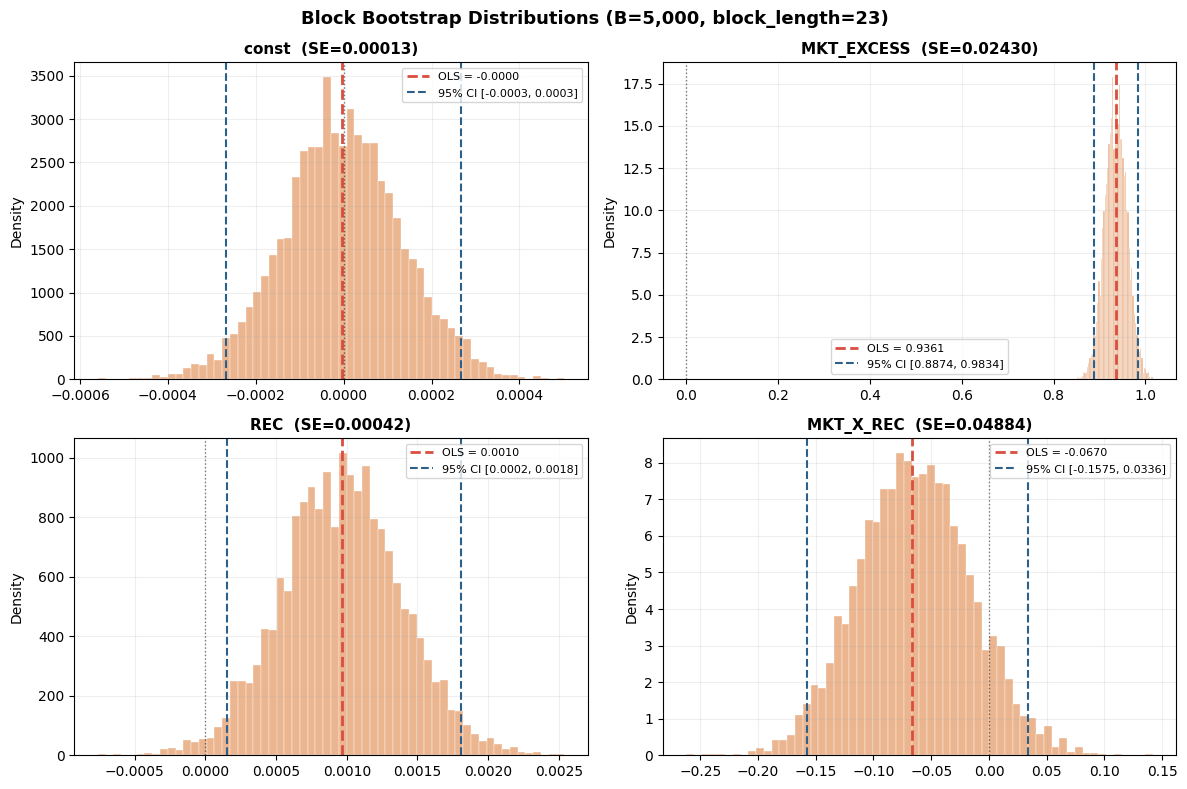

In [4]:
# --------------------
# 6) Block bootstrap (preserves temporal dependence)
# --------------------
B = 5000
rng = np.random.default_rng(0)

# Block length: rule of thumb T^(1/3)
block_len = int(np.ceil(T ** (1 / 3)))
n_blocks = int(np.ceil(T / block_len))

print(f"\nBlock bootstrap: T={T}, block_length={block_len}, "
      f"blocks_per_resample={n_blocks}")

y_arr = y.to_numpy()
X_arr = X.to_numpy()

boot_block = np.zeros((B, X.shape[1]))
for b in range(B):
    starts = rng.integers(0, T - block_len + 1, size=n_blocks)
    idx = np.concatenate([np.arange(s, s + block_len) for s in starts])[:T]
    fit_b = sm.OLS(y_arr[idx], X_arr[idx]).fit()
    boot_block[b, :] = fit_b.params

boot_df = pd.DataFrame(boot_block, columns=X.columns)

# --------------------
# 7) Comparison table: HAC vs Block Bootstrap
# --------------------
alpha = 0.05
summary = pd.DataFrame({
    "coef": res.params,
    "HAC_se": res.bse,
    "block_se": boot_df.std(ddof=1),
    "block_ci_lo": boot_df.quantile(alpha / 2),
    "block_ci_hi": boot_df.quantile(1 - alpha / 2),
})

print(f"\n{'=' * 70}")
print("Comparison: HAC vs Block Bootstrap")
print(f"{'=' * 70}")
print(summary.round(6).to_string())

# --------------------
# 8) Visualisation
# --------------------
params = list(X.columns)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, p in enumerate(params):
    ax = axes[i]
    se = boot_df[p].std(ddof=1)
    ci_lo = boot_df[p].quantile(alpha / 2)
    ci_hi = boot_df[p].quantile(1 - alpha / 2)

    ax.hist(boot_df[p], bins=60, color="#E8A87C", edgecolor="white",
            linewidth=0.3, alpha=0.85, density=True)
    ax.axvline(res.params[p], color="#D94E3F", linewidth=2, linestyle="--",
               label=f"OLS = {res.params[p]:.4f}")
    ax.axvline(ci_lo, color="#2C5F8A", linewidth=1.5, linestyle="--",
               label=f"95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")
    ax.axvline(ci_hi, color="#2C5F8A", linewidth=1.5, linestyle="--")
    ax.axvline(0, color="black", linewidth=1, linestyle=":", alpha=0.5)

    ax.set_title(f"{p}  (SE={se:.5f})", fontweight="bold", fontsize=11)
    ax.legend(fontsize=8, frameon=True)
    ax.grid(True, alpha=0.2)
    ax.set_ylabel("Density")

fig.suptitle(f"Block Bootstrap Distributions (B={B:,}, block_length={block_len})",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("Ch4_BlockBootstrap.png", dpi=300, bbox_inches="tight")
